In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 🔎 Étape 3 : Analyse Exploratoire des Données (EDA) (Squelette Étudiant)

Cette étape correspond au troisième chapitre du cours. L'objectif est d'explorer et de résumer les propriétés statistiques fondamentales de vos données et de réaliser du **Feature Engineering** pour enrichir vos modèles.

### 1. Préparation de l'environnement

In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration Pandas
pd.set_option('display.max_columns', None)

# Chargement du dataset processed
df = pd.read_csv("../data/processed/football_ml_dataset.csv")
print(f"Dataset initial : {df.shape}")

Dataset initial : (28712, 31)


### 2. FEATURE ENGINEERING (Ingénierie de variables)

In [4]:
print("Création de variables dérivées avancées...")

# 1. Variable cyclique ou catégorielle sur l'expérience (Matrice de maturité)
# L'âge a un effet parabolique. On capture cela en créant aussi une variable au carré.
df['age_squared'] = df['age'] ** 2

# 2. Ratio d'efficacité internationale
# Buts par sélection pour mesurer l'impact réel en équipe nationale
df['intl_efficiency'] = df['international_goals'] / (df['international_caps'] + 1)

# 3. Ratio de déclin / dynamique financière
# Différence relative entre la valeur actuelle et la valeur maximale historique
df['value_drop_ratio'] = (df['highest_market_value_in_eur'] - df['market_value_in_eur']) / (df['highest_market_value_in_eur'] + 1)

# 4. Indicateur de discipline (Cartons par minute jouée)
df['cards_per_90'] = ((df['yellow_cards'] + (df['red_cards'] * 2)) / (df['minutes_played'] + 1)) * 90

print(f"Dataset après Feature Engineering : {df.shape}")

Création de variables dérivées avancées...
Dataset après Feature Engineering : (28712, 35)


### 3. ANALYSE VISUELLE AVANCÉE (Insight Majeur 3)

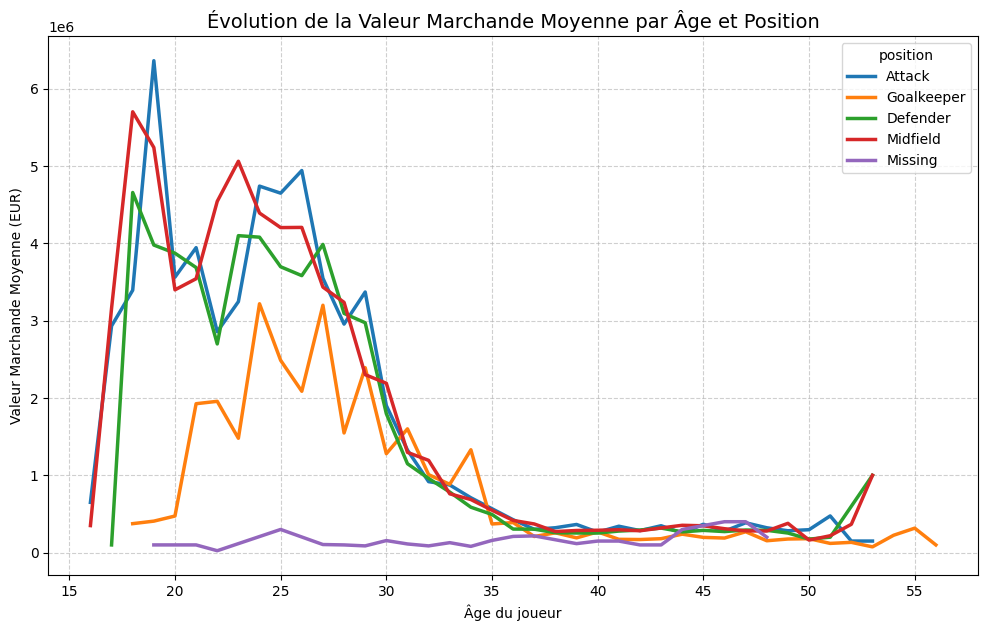

In [5]:
# Analyse de la valeur marchande selon l'âge et le poste occupé
plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='age', y='market_value_in_eur', hue='position', errorbar=None, linewidth=2.5)
plt.title("Évolution de la Valeur Marchande Moyenne par Âge et Position", fontsize=14)
plt.xlabel("Âge du joueur")
plt.ylabel("Valeur Marchande Moyenne (EUR)")
plt.grid(True, linestyle='--', alpha=0.6)

# Sauvegarde de la figure pour le rapport Quarto
os.makedirs("../reports/figures/", exist_ok=True)
plt.savefig("../reports/figures/age_position_valuation.png", dpi=300)
plt.show()

### 4. SAUVEGARDE DU DATASET DE MODÉLISATION

In [6]:
# On écrase ou on crée un fichier final prêt à être ingéré par le Machine Learning
df.to_csv("../data/processed/football_final_features.csv", index=False)
print("[SUCCÈS] Dataset final sauvegardé !")

[SUCCÈS] Dataset final sauvegardé !
